# **RIDGE regression (test) + Portfolio**

In [1]:
import sys
import os

sys.path.append(os.path.abspath("../../Model Kernels"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TestDataFrame

from sklearn.preprocessing import StandardScaler

# ML Stuff
import cvxpy as cp
from sklearn.linear_model import Ridge


In [2]:
# Pre-processed data preparation
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TestDataFrame()

In [3]:
def markowitz(predicted_returns, lambda_risk, cov_matrix):
    '''
    Markowitz portfolio optimization implementation using cvxpy.
    predicted_returns: np.array of predicted returns for each asset
    lambda_risk: risk aversion parameter
    returns: optimal weights for each asset
    '''
    w = cp.Variable(len(predicted_returns))

    objective = cp.Maximize(predicted_returns @ w - lambda_risk * cp.quad_form(w, cov_matrix))

    constraints = [cp.sum(w) == 1, w >= 0]

    problem = cp.Problem(objective, constraints)
    problem.solve()

    return w.value

In [4]:
def markowitz_with_tc(
    predicted_returns,
    cov_matrix,
    prev_weights,
    lambda_risk=20,
    lambda_tc=0.01
):
    """
    Markowitz optimization with transaction cost / turnover penalty.
    """

    n = len(predicted_returns)
    w = cp.Variable(n)

    objective = cp.Maximize(
        predicted_returns @ w
        - lambda_risk * cp.quad_form(w, cov_matrix)
        - lambda_tc * cp.norm1(w - prev_weights)
    )

    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.OSQP)

    return w.value


In [5]:
def markowitz_clean(weights, threshold=1e-6):
    '''
    Cleans the weights by setting very small weights to zero and re-normalizing.
    weights: np.array of weights
    threshold: minimum weight to keep
    returns: cleaned weights
    '''
    weights_cleaned = np.where(weights < threshold, 0, weights)
    if np.sum(weights_cleaned) > 0:
        weights_cleaned /= np.sum(weights_cleaned)
    return weights_cleaned

In [6]:
Stock_Data = pd.read_sql(f"SELECT Ticker, Date, Close FROM StockData ORDER BY Ticker", con=StockDataDatabase, parse_dates=["Date"])

prices_frame = Stock_Data.pivot(index="Date", columns="Ticker", values="Close").sort_index().ffill()
# Historical % returns day-to-day
historical_returns = prices_frame.pct_change().dropna()

# **RIDGE regression**

In [7]:
all_data = {}

for ticker in tickers["Ticker"]:
    df = pd.read_sql(
        f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2022-10-01'",
        con=StockDataDatabase,
        parse_dates=["Date"]
    )
    df = pd.merge(df, TrainingDataFrame, on="Date")
    df["Target"] = df["Close"]
    df = df.dropna().reset_index(drop=True)
    all_data[ticker] = df

In [8]:
training_length = 4 # This was optimized previously
prediction_length = 1

dates = all_data[tickers["Ticker"].iloc[0]]["Date"]

In [9]:
training_length = 4 # This was optimized previously
prediction_length = 1

dates = all_data[tickers["Ticker"].iloc[0]]["Date"]

portfolio_predictions = {}

for t in range(len(dates) - (training_length + prediction_length)):

    current_date = dates.iloc[t + training_length]
    portfolio_predictions[current_date] = {}

    for ticker, Stock_Data in all_data.items():

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            Stock_Data[historic_columns].iloc[t:t+training_length]
        )
        y_train = Stock_Data["Target"].iloc[t:t+training_length]

        X_test = scaler.transform(
            Stock_Data[historic_columns].iloc[t+training_length:t+training_length+prediction_length]
        )

        model = Ridge(alpha=211.85) # This was optimized previously
        model.fit(X_train, y_train)

        prediction = model.predict(X_test)[0]

        pct_return = (prediction - Stock_Data["Close"].iloc[t+training_length-1]) / Stock_Data["Close"].iloc[t+training_length-1]

        portfolio_predictions[current_date][ticker] = pct_return

        print(f"Date: {current_date.date()}, Ticker: {ticker}, Prediction: {pct_return}")


Date: 2022-11-18, Ticker: ACN, Prediction: 0.005115741886563058
Date: 2022-11-18, Ticker: ADBE, Prediction: 0.0018365955565615216
Date: 2022-11-18, Ticker: AMD, Prediction: -0.0018841875690267281
Date: 2022-11-18, Ticker: AKAM, Prediction: 0.0010695899677617806
Date: 2022-11-18, Ticker: APH, Prediction: 0.001327133487193204
Date: 2022-11-18, Ticker: ADI, Prediction: 0.001253909850374963
Date: 2022-11-18, Ticker: AAPL, Prediction: -0.0031792844856004146
Date: 2022-11-18, Ticker: AMAT, Prediction: 0.002343274613840068
Date: 2022-11-18, Ticker: ANET, Prediction: -0.00223552051090591
Date: 2022-11-18, Ticker: ADSK, Prediction: 0.012208502463294163
Date: 2022-11-18, Ticker: AVGO, Prediction: 0.0013524518108007661
Date: 2022-11-18, Ticker: CDNS, Prediction: 0.00696031632392883
Date: 2022-11-18, Ticker: CDW, Prediction: 0.00025781929317708174
Date: 2022-11-18, Ticker: CSCO, Prediction: -0.013667204408117669
Date: 2022-11-18, Ticker: CTSH, Prediction: -0.00035189618655822317
Date: 2022-11-18, 

For benchmarking, we do <code>pct_change()</code> for indices as well, we will benchmark to them.

In [10]:
snp = pd.read_sql("SELECT Date, Close FROM Indexes WHERE IndexName='S&P 500'", con=StockDataDatabase, parse_dates=["Date"])

snp["Return"] = snp["Close"].pct_change()

snp = snp.dropna()

In [11]:
nasdaq = pd.read_sql("SELECT Date, Close FROM Indexes WHERE IndexName='NASDAQ'", con=StockDataDatabase, parse_dates=["Date"])

nasdaq["Return"] = nasdaq["Close"].pct_change()
nasdaq = nasdaq.dropna()

In [12]:
def simulate_portfolio(
    lambda_risk=20,
    cov_window=60,
    lambda_tc=0.01,
    reportion=False,
    naive=False
):
    '''
    Complete portfolio simulation with Markowitz optimization and transaction costs.
    lambda_risk: risk aversion parameter
    cov_window: window size for covariance matrix estimation
    lambda_tc: transaction cost penalty parameter
    reportion: if True, prints progress reports
    returns: portfolio values, benchmark values, weights history, turnover history
    '''
    initial_capital = 100

    capital = initial_capital
    capital_benchmark1 = initial_capital
    capital_benchmark2 = initial_capital

    portfolio_values = []
    snp_values = []
    nasdaq_values = []

    weights_history = []
    turnover_history = []

    t_start = 30 # Adjusted based on shifts, more than in naive

    # Explicit, no trading previously
    prev_weights = np.zeros(len(historical_returns.columns))

    for t in range(t_start, len(dates) - (training_length + prediction_length)):

        current_date = dates.iloc[t + training_length]

        # Covariance estimation
        covariance_data = historical_returns.loc[:current_date].tail(cov_window)
        cov_matrix = covariance_data.cov().values
        cov_matrix += 1e-6 * np.eye(cov_matrix.shape[0])

        # Predicted returns
        if not naive:
            predicted_returns = np.array(
                list(portfolio_predictions[current_date].values())
            )
        else:
            predicted_returns = np.zeros(len(historical_returns.columns))

        # Portfolio optimization with turnover penalty
        optimal_weights = markowitz_clean(
            markowitz_with_tc(
                predicted_returns,
                cov_matrix=cov_matrix,
                prev_weights=prev_weights,
                lambda_risk=lambda_risk,
                lambda_tc=lambda_tc
            )
        )

        # Realized returns, based on next day after prediction
        next_day_index = t + training_length + prediction_length
        realized_r = historical_returns.iloc[next_day_index].values

        realized_bench = snp.iloc[next_day_index]["Return"]
        realized_nasdaq = nasdaq.iloc[next_day_index]["Return"]

        # Update portfolio values
        portfolio_return = np.dot(optimal_weights, realized_r)

        capital *= (1 + portfolio_return)
        capital_benchmark1 *= (1 + realized_bench)
        capital_benchmark2 *= (1 + realized_nasdaq)

        # Well, well, well...
        turnover = np.sum(np.abs(optimal_weights - prev_weights))

        portfolio_values.append(capital)
        snp_values.append(capital_benchmark1)
        nasdaq_values.append(capital_benchmark2)

        weights_history.append(optimal_weights)
        turnover_history.append(turnover)

        prev_weights = optimal_weights.copy()

        if reportion:
            print(
                f"Date: {current_date + pd.Timedelta(days=1)}, "
                f"Capital: {capital:.2f}, "
                f"Turnover: {turnover:.2f}"
            )

    return (
        np.array(portfolio_values),
        np.array(snp_values),
        np.array(nasdaq_values),
        np.array(weights_history),
        np.array(turnover_history),
    )


# **Test evaluation**


In [13]:
# Some simulations with different risk aversion levels, to visually compare
conservative, snp_values, nasdaq_values, _, _ = simulate_portfolio(lambda_risk=1200, reportion=True)

Date: 2023-01-05 00:00:00, Capital: 99.66, Turnover: 1.00
Date: 2023-01-06 00:00:00, Capital: 98.81, Turnover: 0.02
Date: 2023-01-07 00:00:00, Capital: 99.16, Turnover: 0.05
Date: 2023-01-10 00:00:00, Capital: 100.77, Turnover: 0.07
Date: 2023-01-11 00:00:00, Capital: 101.01, Turnover: 0.21
Date: 2023-01-12 00:00:00, Capital: 100.95, Turnover: 0.08
Date: 2023-01-13 00:00:00, Capital: 100.92, Turnover: 0.11
Date: 2023-01-14 00:00:00, Capital: 99.01, Turnover: 0.03
Date: 2023-01-18 00:00:00, Capital: 99.08, Turnover: 0.03
Date: 2023-01-19 00:00:00, Capital: 98.23, Turnover: 0.05
Date: 2023-01-20 00:00:00, Capital: 98.14, Turnover: 0.25
Date: 2023-01-21 00:00:00, Capital: 98.44, Turnover: 0.02
Date: 2023-01-24 00:00:00, Capital: 97.51, Turnover: 0.04
Date: 2023-01-25 00:00:00, Capital: 97.20, Turnover: 0.02
Date: 2023-01-26 00:00:00, Capital: 96.78, Turnover: 0.00
Date: 2023-01-27 00:00:00, Capital: 96.92, Turnover: 0.03
Date: 2023-01-28 00:00:00, Capital: 96.20, Turnover: 0.00
Date: 2023

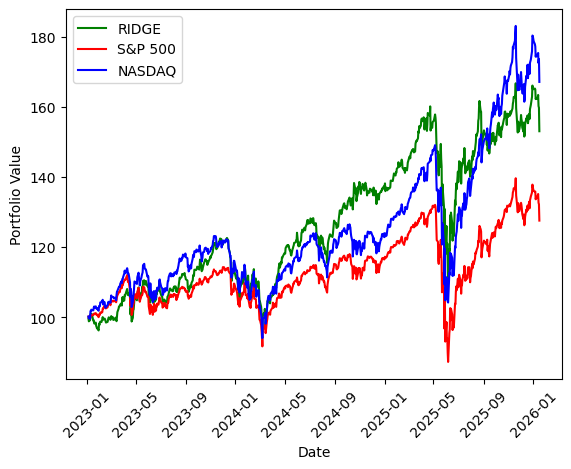

In [14]:
plt.plot(dates[35:], conservative, c="green")
plt.plot(dates[35:], snp_values, c="red")
plt.plot(dates[35:], nasdaq_values, c="blue")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.legend(["RIDGE", "S&P 500", "NASDAQ"])

plt.xticks(rotation=45)

plt.show()

In [15]:
for i in conservative:
    print(i)

99.65868869719509
98.80853623014647
99.1552700846165
100.77417655054704
101.010384981898
100.94592876114542
100.92099318729288
99.01167181208666
99.08388165680701
98.22832510337398
98.14191494684951
98.44330461493826
97.50522991400145
97.19516188901365
96.77516056136092
96.91792154490838
96.20099159474275
98.11985027067031
97.7534556069603
98.49173525399145
98.71355577907642
98.58387310988144
99.07378260745541
99.31547999788322
99.99880747258504
99.25877099162413
99.5548768372339
99.56818151972061
99.2856214177932
98.80670969033281
98.44860710720666
98.6516313331854
99.18513306377876
99.70512566110636
99.94301528728742
99.47574983798845
99.23324695901401
99.45174272963408
100.29460915027033
99.89616107942935
99.97530294545648
99.19241320472399
99.23692920260929
99.26248903535064
99.48662783430713
99.86770287406074
99.13465546887285
98.83963630257963
100.28026211263101
101.42469691431101
102.4168348154395
103.05274897540664
103.11064998587483
103.13026956200136
103.5935485987177
103.939

In [15]:
def cagr(portfolio_values, periods_per_year=252):
    '''
    Calculate the Compound Annual Growth Rate (CAGR) of a portfolio.
    portfolio_values: list or np.array of portfolio values over time
    periods_per_year: number of periods in a year (e.g., 252 for daily data)
    returns: CAGR value
    '''
    years = len(portfolio_values) / periods_per_year
    cagr_value = (portfolio_values[-1] / portfolio_values[0]) ** (1 / years) - 1
    return 100*cagr_value

In [16]:
def volatility(portfolio_values, periods_per_year=252):
    '''
    Calculate the annualized volatility of a portfolio.
    portfolio_values: list or np.array of portfolio values over time
    periods_per_year: number of periods in a year (e.g., 252 for daily data)
    returns: annualized volatility value
    '''
    return 100*np.std(portfolio_values[1:] / portfolio_values[:-1] - 1) * np.sqrt(periods_per_year)


In [17]:
def sharpe_ratio(portfolio_values):
    '''
    Calculate the Sharpe Ratio of a portfolio.
    portfolio_values: list or np.array of portfolio values over time
    returns: Sharpe Ratio value
    '''
    return cagr(portfolio_values) / volatility(portfolio_values)

In [18]:
print("Portfolio:", cagr(conservative), "% CAGR,", volatility(conservative), "% Volatility,", sharpe_ratio(conservative), "Sharpe Ratio")
print("Portfolio:", cagr(snp_values), "% CAGR,", volatility(snp_values), "% Volatility,", sharpe_ratio(snp_values), "Sharpe Ratio")
print("Portfolio:", cagr(nasdaq_values), "% CAGR,", volatility(nasdaq_values), "% Volatility,", sharpe_ratio(nasdaq_values), "Sharpe Ratio")


Portfolio: 15.298480867118958 % CAGR, 25.243115431772825 % Volatility, 0.6060456724712819 Sharpe Ratio
Portfolio: 8.349759251172472 % CAGR, 23.09565812355316 % Volatility, 0.36152939251630645 Sharpe Ratio
Portfolio: 18.510114682412837 % CAGR, 25.147331479628452 % Volatility, 0.7360667551309632 Sharpe Ratio
